# Clustering với k-Means

In [1]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt

np.set_printoptions(precision=3, suppress=True)

## 1. Dữ liệu giả định

**Giả sử có 3 tập**
1. Set 1: 50 điểm
1. Set 2: 75 điểm
1. Set 3: 100 điểm

In [2]:
np.random.seed(1)
x1,y1 = np.random.normal(loc=2,scale=1,size=50), np.random.normal(loc=5,scale=1,size=50)
x2,y2 = np.random.normal(loc=5,scale=1,size=75), np.random.normal(loc=1,scale=1,size=75)
x3,y3 = np.random.normal(loc=8,scale=1,size=100), np.random.normal(loc=7,scale=1,size=100)

**=== Hiển thị 3 tập để kiểm tra ===**

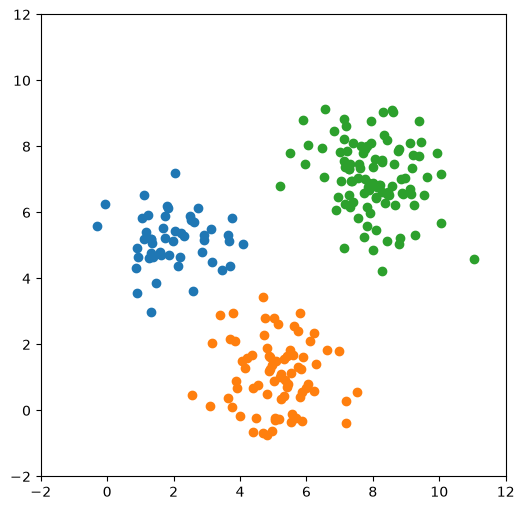

In [3]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(x1, y1)
plt.scatter(x2, y2)
plt.scatter(x3, y3)
plt.show()

### Ghép nối dữ liệu lại thành 1 tập chưa được clustered

In [61]:
# Ghép 3 tập dữ liệu thành 1 tập chưa được clustered
X = np.concatenate([
    np.column_stack((x1, y1)),
    np.column_stack((x2, y2)),
    np.column_stack((x3, y3))
])

print(X.shape)

(225, 2)


In [64]:
dat1 = np.stack([x1, y1]).T
dat2 = np.stack([x2, y2]).T
dat3 = np.stack([x3, y3]).T

dat = np.concatenate([dat1, dat2, dat3])

print(dat.shape)

(225, 2)


**=== Tập dữ liệu giả định có 225 dòng, 2 cột (x,y) ===**

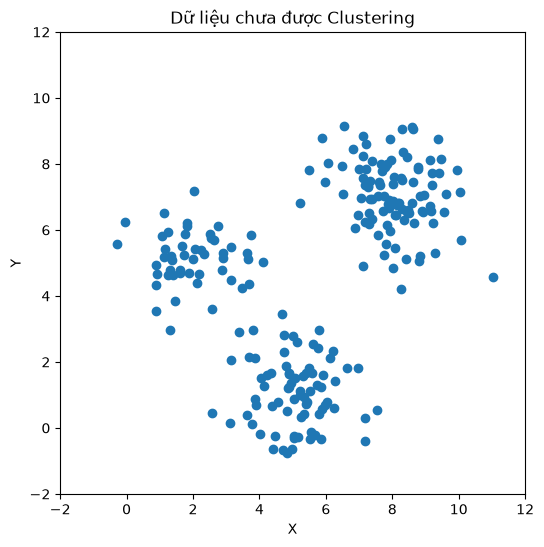

In [65]:
plt.figure(figsize=(6,6))

plt.scatter(X[:, 0], X[:, 1])

plt.xlim([-2, 12])
plt.ylim([-2, 12])

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Dữ liệu chưa được Clustering")

plt.show()


### Sắp ngẫu nhiên các dòng

In [66]:
np.random.seed(2)
np.random.shuffle(X)

### Kiểm tra lại với biểu đồ scatter

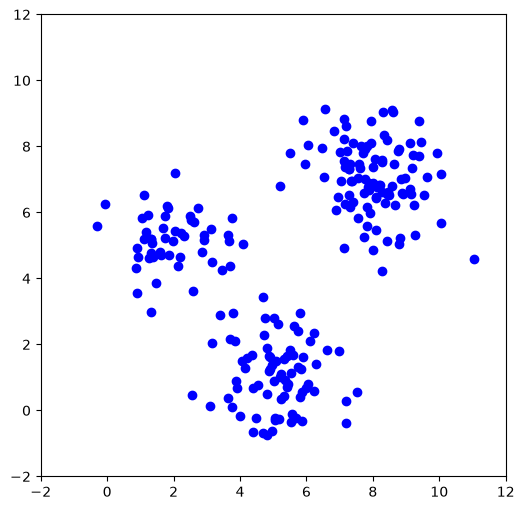

In [67]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='b')
plt.show()

## 2. Thực hiện phân cụm

### 2.1. Giả sử K=3 và tìm 3 điểm ban đầu ngẫu nhiên

In [76]:
K = 3

**Gán các trung tâm cho 3 điểm này**

In [77]:
np.random.seed(30)
centers = dat[np.random.choice(len(dat), 3, replace=False)]
print(centers)


[[2.319 5.286]
 [9.623 7.086]
 [7.703 7.795]]


**=== Vẽ K điểm centroids ban đầu lên biểu đồ ===**

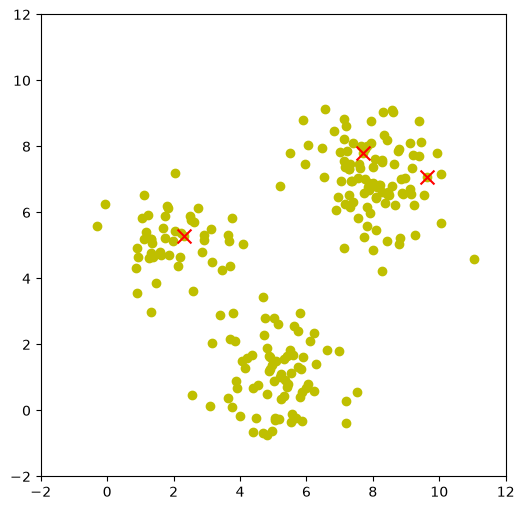

In [78]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centers[:,0], centers[:,1], color='r', marker='x', s=100)

plt.show()

### 2.2. Tiến hành gom cụm lần 1

**=== Khởi tạo K danh sách rỗng (để chứa các điểm của mỗi cluster) ===**

In [79]:
cList = [[] for _ in range(K)]

print(cList)

[[], [], []]


**=== Với mỗi sample, tìm xem nó gần điểm centroid nào nhất ===**

In [80]:
for sample in dat:
    distances = np.linalg.norm(centers - sample, axis=1)
    nearest = np.argmin(distances)
    cList[nearest].append(sample)
    

In [81]:
# Thử kiểm tra lại mỗi list
for i in range(K): 
    print(len(cList[i]))

124
33
68


**=== Thử lấy cluster đầu tiên ra và đánh giá ===**

In [82]:
np.stack(cList[0]).shape

(124, 2)

In [83]:
# Tọa độ của điểm centroid mới
new_centroid = np.mean(cList[0], axis=0)

print(new_centroid)

[3.812 2.728]


**=== Tính lại các điểm centroids ===**

In [84]:
centers = np.array([
    np.mean(cList[i], axis=0)
    for i in range(K)
])

print(centers)

[[3.812 2.728]
 [9.01  6.31 ]
 [7.527 7.334]]


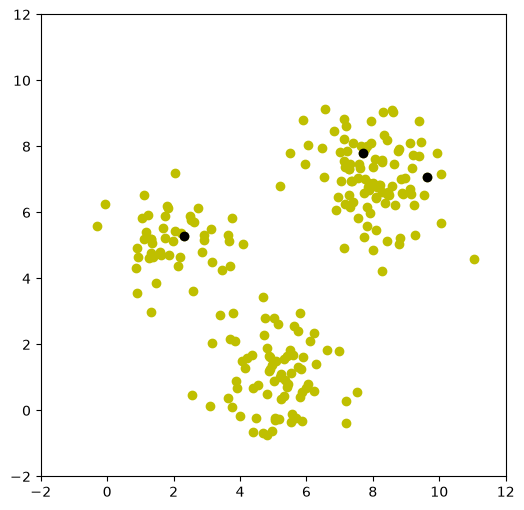

In [85]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.3. Tiến hành gom cụm lần 2

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [ ]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

# Tính giá trị của các centroids mới
centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.036 1.22 ]
 [1.861 5.185]
 [8.016 7.064]]


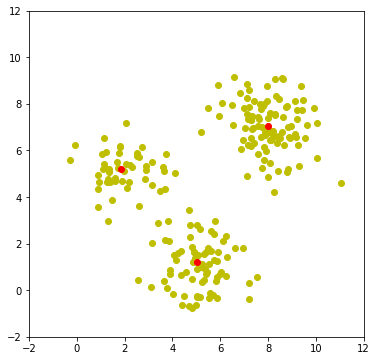

In [ ]:
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(dat[:,0], dat[:,1], color='y')
plt.scatter(centroids[:,0], centroids[:,1], color='k')

plt.show()

### 2.4. Tiến hành gom cụm lần 3

**=== Tiếp tục khởi tạo K list rỗng để chứa các cluster mới ===**

In [ ]:
cList = [[] for _ in range(K)]
for sample in dat:
    kq = np.sum((sample - centroids)**2, axis=1)
    min_d_idx = np.argmin(kq)
    cList[min_d_idx].append(sample)

centroids = [np.stack(cList[i]).mean(axis=0) for i in range(K)]
centroids = np.stack(centroids)
print(centroids)

[[5.087 1.087]
 [1.974 5.147]
 [8.016 7.064]]


**==> Nhận xét: các giá trị trung tâm gần như ít thay đổi**

In [86]:
# Lấy ra các cluster
clusters = [np.stack(cList[i]) for i in range(K)]


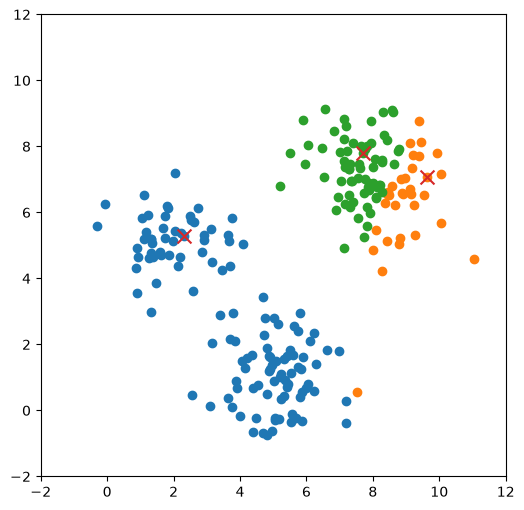

In [87]:
# Hiển thị 3 cluster lên biểu đồ
fig = plt.figure(figsize=(6,6))
plt.xlim([-2,12])
plt.ylim([-2,12])

plt.scatter(np.stack(cList[0])[:,0], np.stack(cList[0])[:,1])
plt.scatter(np.stack(cList[1])[:,0], np.stack(cList[1])[:,1])
plt.scatter(np.stack(cList[2])[:,0], np.stack(cList[2])[:,1])

plt.scatter(centroids[:,0], centroids[:,1], marker='x', s=100)

plt.show()